### Example diagram 

> show an image along its counterfactual, and what the QC model used to correctly predict its quality

- One chest X-ray image (xi)
- Its nearest-opposite-neighbour (xcf)
- The ΔA vector, with the top most discriminative attributes highlighted
- The C2 output score for that case

-> Do this for a correct and a wrong prediction
# ══════════════════════════════════════════════════════════════════════════════

In [1]:
import pandas as pd

In [2]:
DATA_DIR = "/zhome/d0/a/221493/thesis/data/"
BASE_DIR = "/zhome/d0/a/221493/thesis/code/"
RESULTS_DIR = "/zhome/d0/a/221493/thesis/results/"

In [3]:
# Select a sample from C0 prediction CSV.
valid_csv = f"{RESULTS_DIR}/C0_baseline/effusion/valid_c0_effusion.csv"
df = pd.read_csv(valid_csv)
correct_c0_sample = df.loc[df['true'] == df['pred']].iloc[0]
incorrect_c0_sample = df.loc[df['true'] != df['pred']].iloc[0]

In [4]:
for sample in [correct_c0_sample, incorrect_c0_sample]:
    c0_prob = sample['prob']
    true_label = sample['true']
    pred_label = sample['pred']
    margin = sample['margin']
    correct = sample['correct']
    
    print(f"True Label: {true_label}")
    print(f"Predicted Label: {pred_label}")
    print(f"Predicted Probability: {c0_prob:.4f}")
    print(f"Margin: {margin:.4f}")
    print(f"Correctly Classified: {correct}")
    print("-" * 40)
        

True Label: 0.0
Predicted Label: 0
Predicted Probability: 0.5094
Margin: 0.1451
Correctly Classified: 1
----------------------------------------
True Label: 1.0
Predicted Label: 0
Predicted Probability: 0.6152
Margin: 0.0392
Correctly Classified: 0
----------------------------------------


Correct Prediction Image Path: /zhome/d0/a/221493/thesis/data/CheXpert-v1.0-small/valid/patient64542/study1/view1_frontal.jpg
Incorrect Prediction Image Path: /zhome/d0/a/221493/thesis/data/CheXpert-v1.0-small/valid/patient64541/study1/view1_frontal.jpg


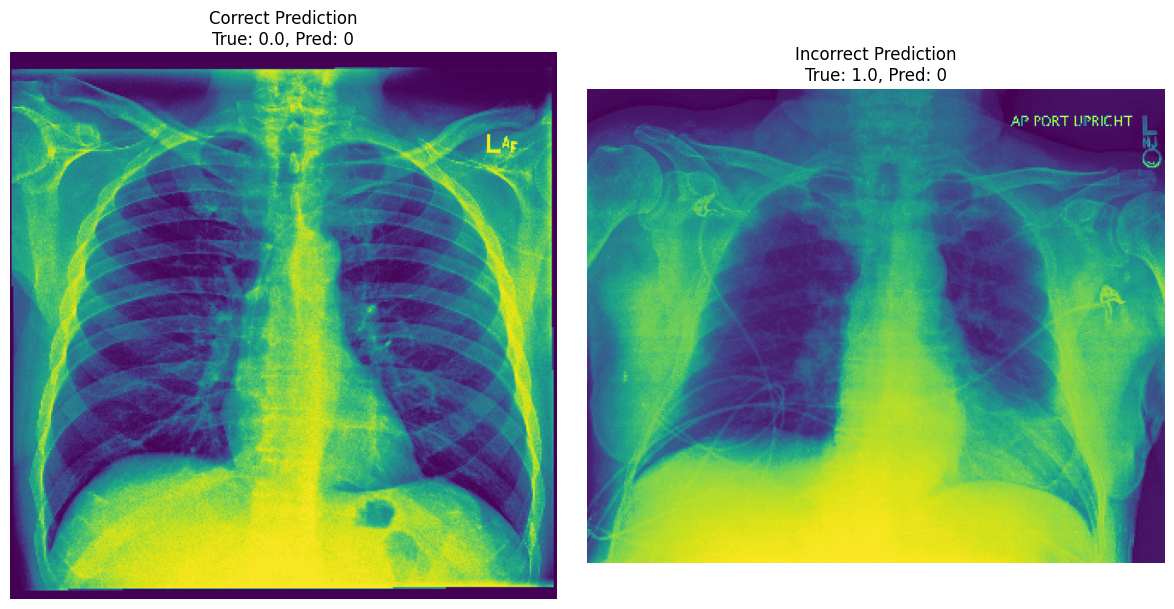

In [5]:
# View Image
from PIL import Image
import matplotlib.pyplot as plt
correct_c0_image_path = DATA_DIR + correct_c0_sample['path']
print(f"Correct Prediction Image Path: {correct_c0_image_path}")
incorrect_c0_image_path = DATA_DIR + incorrect_c0_sample['path']
print(f"Incorrect Prediction Image Path: {incorrect_c0_image_path}")

# Display both in a single figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Correct Prediction
correct_image = Image.open(correct_c0_image_path)
axes[0].imshow(correct_image)
axes[0].set_title(f"Correct Prediction\nTrue: {correct_c0_sample['true']}, Pred: {correct_c0_sample['pred']}")
axes[0].axis('off')
# Incorrect Prediction
incorrect_image = Image.open(incorrect_c0_image_path)
axes[1].imshow(incorrect_image)
axes[1].set_title(f"Incorrect Prediction\nTrue: {incorrect_c0_sample['true']}, Pred: {incorrect_c0_sample['pred']}")
axes[1].axis('off')
plt.tight_layout()
plt.show()